In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import gymnasium as gym

from pprint import pprint

import seaborn as sns

import gymnasium as gym

from pathlib import Path

In [ ]:
from OBJETIVO1.custom_env_tabular import CustomEnvTabular

In [3]:
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)

# 1. Cargamos datos

## 1.1 Definimos paths principales

In [4]:
#Esto funciona en notebook, en .py es con __file__

CURRENT_DIR = Path.cwd()
PROJECT_ROOT = CURRENT_DIR.parent
print(PROJECT_ROOT)

c:\Users\nerea\Desktop\MASTER_IA\RETO3\CODE\Reto3_MicroRedes


## 1.2 Definimos paths a los .csv

In [5]:
price_path=PROJECT_ROOT / "OBJETIVO1" / "data" / "external"  / "precio2025-peninsula.csv"
pv_aprox_path=PROJECT_ROOT / "OBJETIVO1" / "data" / "processed"  /"pv_kw_aprox_timeseries.csv"
pv_path=PROJECT_ROOT / "OBJETIVO1" / "data" / "raw"  / "pv" /"SanFrancisco_724940TYA.csv"
load_path=PROJECT_ROOT/"OBJETIVO1"/"data"/"raw"/"load"/ "RefBldgFullServiceRestaurantNew2004_v1.3_7.1_6A_USA_MN_MINNEAPOLIS.csv"


## 1.3 Cargamos datos en df

In [6]:
df_price = pd.read_csv(price_path, sep=";")
df_pv_aprox = pd.read_csv(pv_aprox_path)
df_pv = pd.read_csv(pv_path)
df_load=pd.read_csv(load_path)

## 1.4 Visualizamos datos

In [7]:
print("PRICE")
display(df_price.head())

print("PV APROX")
display(df_pv_aprox.head())

print("PV")
display(df_pv.head())

print("LOAD")
display(df_load.head())

PRICE


,id,name,geoid,geoname,value,datetime
0,1001,Término de facturación de energía activa del P...,8741,Península,182.79,2025-01-01T00:00:00+01:00
1,1001,Término de facturación de energía activa del P...,8741,Península,183.19,2025-01-01T01:00:00+01:00
2,1001,Término de facturación de energía activa del P...,8741,Península,188.74,2025-01-01T02:00:00+01:00
3,1001,Término de facturación de energía activa del P...,8741,Península,187.77,2025-01-01T03:00:00+01:00
4,1001,Término de facturación de energía activa del P...,8741,Península,180.19,2025-01-01T04:00:00+01:00


PV APROX


,GH_illum_lx,irradiance_wm2,pv_kw
0,0.0,0.0,0.0
1,0.0,0.0,0.0
2,0.0,0.0,0.0
3,0.0,0.0,0.0
4,0.0,0.0,0.0


PV


,GH illum (lx)
0,0
1,0
2,0
3,0
4,0


LOAD


,Electricity:Facility [kW](Hourly)
0,22.321537
1,14.644444
2,14.664632
3,14.676162
4,14.826450


In [8]:
print("=== PRICE ===")
print(df_price.shape)
print(df_price.columns.tolist())
print(df_price.isna().sum())

print("\n=== PV APROX ===")
print(df_pv_aprox.shape)
print(df_pv_aprox.columns.tolist())
print(df_pv_aprox.isna().sum())

print("\n=== PV ===")
print(df_pv.shape)
print(df_pv.columns.tolist())
print(df_pv.isna().sum())

print("\n=== LOAD ===")
print(df_load.shape)
print(df_load.columns.tolist())
print(df_load.isna().sum())

=== PRICE ===
(8760, 6)
['id', 'name', 'geoid', 'geoname', 'value', 'datetime']
id          0
name        0
geoid       0
geoname     0
value       0
datetime    0
dtype: int64

=== PV APROX ===
(8760, 3)
['GH_illum_lx', 'irradiance_wm2', 'pv_kw']
GH_illum_lx       0
irradiance_wm2    0
pv_kw             0
dtype: int64

=== PV ===
(8760, 1)
['GH illum (lx)']
GH illum (lx)    0
dtype: int64

=== LOAD ===
(8760, 1)
['Electricity:Facility [kW](Hourly)']
Electricity:Facility [kW](Hourly)    0
dtype: int64


## 1.5 Identificar que columna usar en cada csv

In [9]:
print("PRICE sample values:")
for col in df_price.columns:
    print(f"\nColumna: {col}")
    print(df_price[col].head(10).tolist())

print("\nPV APROX sample values:")
for col in df_pv_aprox.columns:
    print(f"\nColumna: {col}")
    print(df_pv_aprox[col].head(10).tolist())

print("\nPV sample values:")
for col in df_pv.columns:
    print(f"\nColumna: {col}")
    print(df_pv[col].head(10).tolist())

print("\nLOAD sample values:")
for col in df_load.columns:
    print(f"\nColumna: {col}")
    print(df_load[col].head(10).tolist())

PRICE sample values:

Columna: id
[1001, 1001, 1001, 1001, 1001, 1001, 1001, 1001, 1001, 1001]

Columna: name
['Término de facturación de energía activa del PVPC 2.0TD Península', 'Término de facturación de energía activa del PVPC 2.0TD Península', 'Término de facturación de energía activa del PVPC 2.0TD Península', 'Término de facturación de energía activa del PVPC 2.0TD Península', 'Término de facturación de energía activa del PVPC 2.0TD Península', 'Término de facturación de energía activa del PVPC 2.0TD Península', 'Término de facturación de energía activa del PVPC 2.0TD Península', 'Término de facturación de energía activa del PVPC 2.0TD Península', 'Término de facturación de energía activa del PVPC 2.0TD Península', 'Término de facturación de energía activa del PVPC 2.0TD Península']

Columna: geoid
[8741, 8741, 8741, 8741, 8741, 8741, 8741, 8741, 8741, 8741]

Columna: geoname
['Península', 'Península', 'Península', 'Península', 'Península', 'Península', 'Península', 'Península',

## 1.6 Graficar precios, las dos series de PV y LOAD 

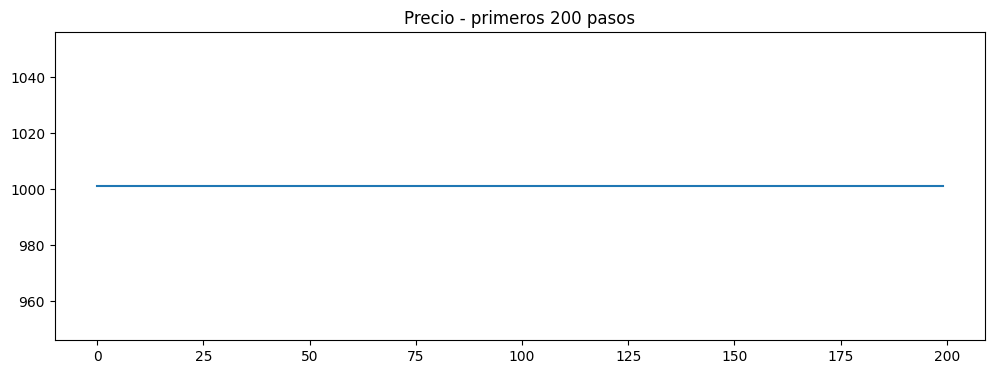

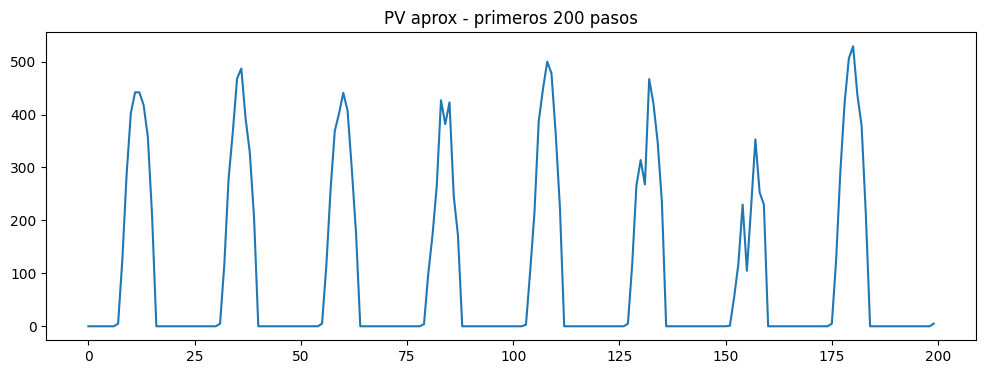

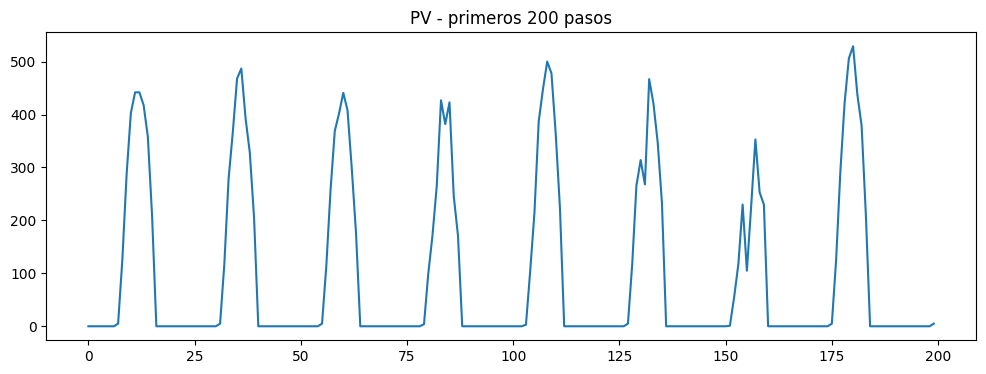

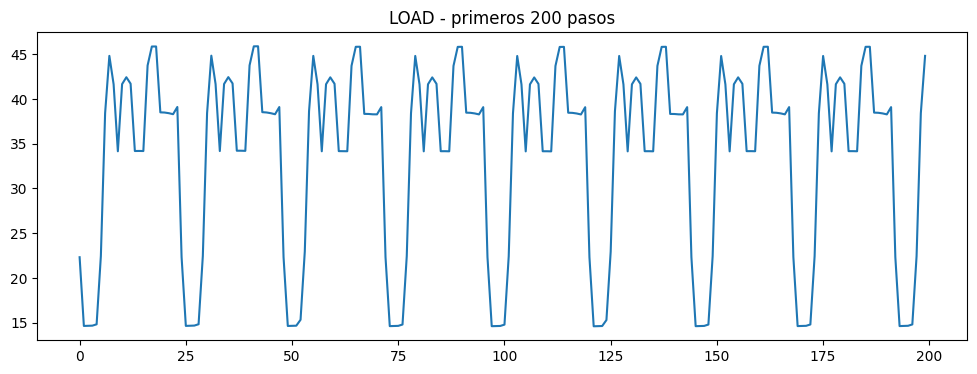

In [10]:
plt.figure(figsize=(12, 4))
plt.plot(df_price.iloc[:, 0].values[:200])
plt.title("Precio - primeros 200 pasos")
plt.show()

plt.figure(figsize=(12, 4))
plt.plot(df_pv_aprox.iloc[:, 0].values[:200])
plt.title("PV aprox - primeros 200 pasos")
plt.show()

plt.figure(figsize=(12, 4))
plt.plot(df_pv.iloc[:, 0].values[:200])
plt.title("PV - primeros 200 pasos")
plt.show()

plt.figure(figsize=(12, 4))
plt.plot(df_load.iloc[:, 0].values[:200])
plt.title("LOAD - primeros 200 pasos")
plt.show()

## 1.7 Datos que usaremos

In [11]:
hourly_prices = df_price["value"].to_numpy(dtype=float)
#Conversion de MW a kW:
hourly_prices = hourly_prices / 1000.0   # €/kWh

In [12]:
pv_series = df_pv_aprox["pv_kw"].to_numpy(dtype=float)

In [13]:
load_series = df_load["Electricity:Facility [kW](Hourly)"].to_numpy(dtype=float)

### Verificación

In [14]:
print("PRICE:", hourly_prices.shape)
print("PV:", pv_series.shape)
print("LOAD:", load_series.shape)

PRICE: (8760,)
PV: (8760,)
LOAD: (8760,)


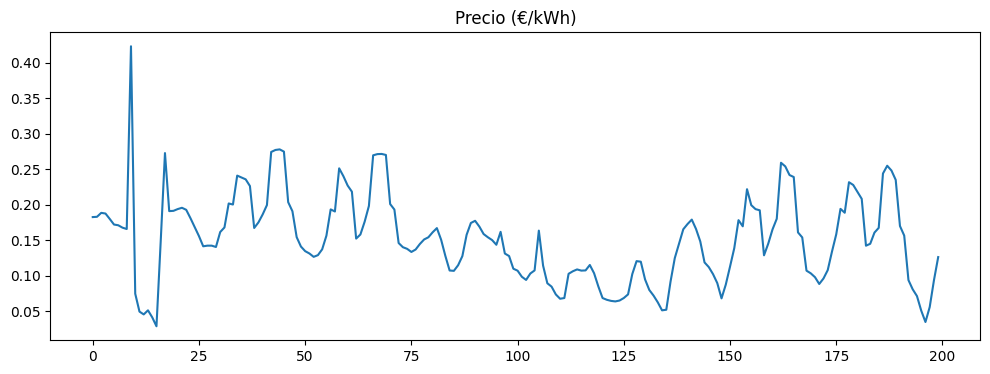

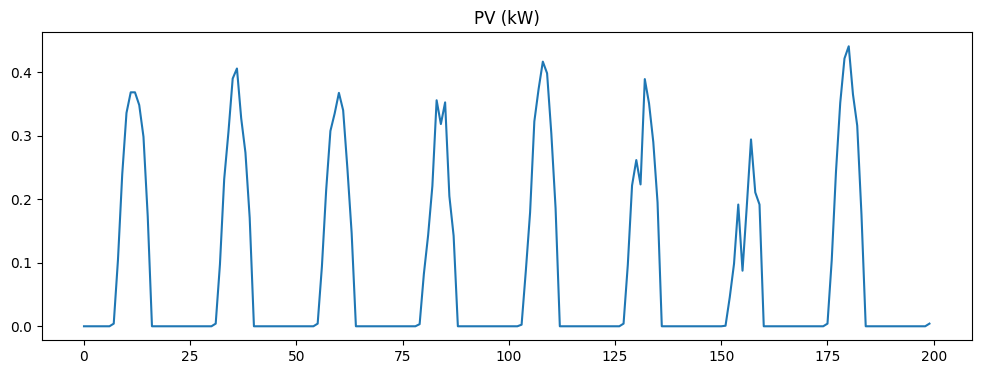

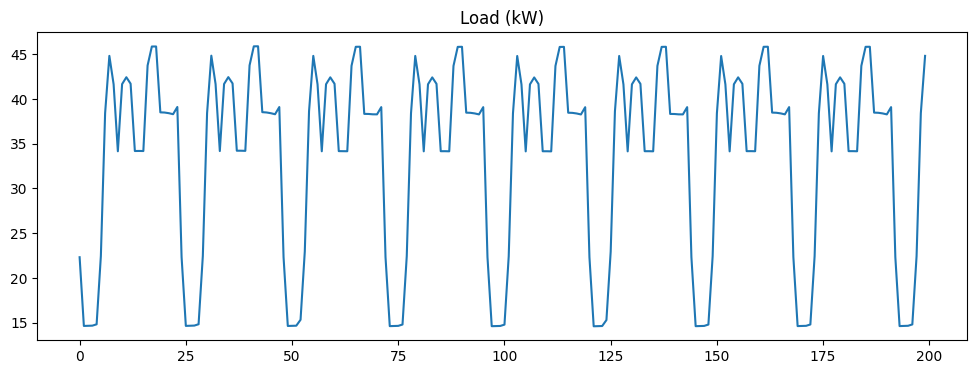

In [15]:
plt.figure(figsize=(12,4))
plt.plot(hourly_prices[:200])
plt.title("Precio (€/kWh)")
plt.show()

plt.figure(figsize=(12,4))
plt.plot(pv_series[:200])
plt.title("PV (kW)")
plt.show()

plt.figure(figsize=(12,4))
plt.plot(load_series[:200])
plt.title("Load (kW)")
plt.show()

# Comprobación de la integración de datos externos en `pymgrid`

En esta etapa no se pretende todavía entrenar ningún agente de *Reinforcement Learning*.  
El objetivo es realizar una **validación técnica del simulador y de la representación de la microred** antes de avanzar hacia el diseño definitivo del entorno RL.

## ¿Por qué es necesaria esta etapa?

En una primera aproximación se había planteado un entorno en el que:

- la demanda (`load_series`),
- la generación fotovoltaica (`pv_series`),
- y el precio horario (`hourly_prices`)

se leían manualmente desde arrays externos dentro del entorno personalizado, mientras que `pymgrid` se utilizaba principalmente para modelar la batería y ejecutar las acciones.

Sin embargo, antes de continuar con el entrenamiento era necesario verificar si esta estrategia era realmente coherente con el funcionamiento interno de `pymgrid`, o si, por el contrario, la librería ya permitía integrar directamente estas series temporales en la propia microred.

## Objetivos concretos de estas comprobaciones

Durante esta fase se persiguen los siguientes objetivos:

1. **Verificar la consistencia de los datos externos**
   - Comprobar dimensiones y formato de `hourly_prices`, `load_series` y `pv_series`.
   - Confirmar que las tres series tienen la misma longitud temporal y que sus valores son razonables.

2. **Inspeccionar la API real de `pymgrid`**
   - Identificar qué módulos están disponibles en la versión instalada.
   - Analizar las firmas de:
     - `BatteryModule`
     - `LoadModule`
     - `RenewableModule`
     - `GridModule`
   - Entender qué argumentos necesita cada uno.

3. **Comprobar si `pymgrid` admite directamente nuestros datos**
   - Construir módulos a partir de:
     - la demanda real,
     - la generación fotovoltaica procesada,
     - y los precios horarios de compra/venta.
   - Validar si es posible definir una microred coherente sin gestionar manualmente esas series fuera del simulador.

4. **Entender cómo representa internamente el sistema**
   - Inspeccionar el resultado de `mg.reset()`.
   - Leer los valores actuales de:
     - carga,
     - generación PV,
     - estado de carga de batería,
     - precio de importación/exportación.
   - Confirmar que la microred está utilizando correctamente las series temporales proporcionadas.

5. **Entender cómo espera `pymgrid` las acciones**
   - Inspeccionar el formato devuelto por:
     - `mg.get_empty_action()`
     - `mg.sample_action()`
   - Verificar si las acciones se expresan en unidades físicas explícitas o como variables normalizadas por módulo.

## Importancia de esta etapa para el entorno RL

Esta fase es fundamental porque condiciona el diseño posterior del entorno personalizado.

Si `pymgrid` ya incorpora internamente:
- la carga,
- la generación renovable,
- la red eléctrica,
- y el almacenamiento,

entonces el entorno RL **no debería duplicar esa lógica manualmente**.  
En su lugar, debería limitarse a:

- observar el estado actual de la microred,
- transformar la acción del agente al formato esperado por `pymgrid`,
- ejecutar un paso de simulación,
- y utilizar el reward/coste resultante.

Por tanto, antes de definir definitivamente:
- estados,
- acciones,
- rewards,
- penalizaciones,
- y normalización,

es imprescindible comprender con precisión cómo funciona `pymgrid` y qué parte del modelado físico ya está resuelta por la librería.

In [16]:
print("CustomEnvTabular" in globals())
print("hourly_prices" in globals())
print("load_series" in globals())
print("pv_series" in globals())
print("mg" in globals())

True
True
True
True
False


Observamos que mg sin definir, procedemos a definirla 

In [17]:
print("len(hourly_prices):", len(hourly_prices))
print("len(load_series):", len(load_series))
print("len(pv_series):", len(pv_series))

print("\nPrimeros 5 precios:", hourly_prices[:5])
print("Primeros 5 load:", load_series[:5])
print("Primeros 5 pv:", pv_series[:5])

len(hourly_prices): 8760
len(load_series): 8760
len(pv_series): 8760

Primeros 5 precios: [0.18279 0.18319 0.18874 0.18777 0.18019]
Primeros 5 load: [22.32153712 14.64444443 14.66463229 14.67616229 14.82645007]
Primeros 5 pv: [0. 0. 0. 0. 0.]


In [18]:
debug_horizon = 24 * 3   # 3 días
print("debug_horizon =", debug_horizon)

debug_horizon = 72


In [19]:
import pymgrid
from pymgrid import Microgrid

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
Users of this version of Gym should be able to simply replace 'import gym' with 'import gymnasium as gym' in the vast majority of cases.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


In [20]:
print(dir(pymgrid))

['Microgrid', 'MicrogridGenerator', 'NonModularMicrogrid', 'PROJECT_PATH', 'Path', '__builtins__', '__cached__', '__doc__', '__file__', '__loader__', '__name__', '__package__', '__path__', '__spec__', '__version__', '_deprecated', 'forecast', 'microgrid', 'modules', 'utils', 'version']


In [21]:
from pymgrid import modules

print(dir(modules))

['BatteryModule', 'GensetModule', 'GridModule', 'LoadModule', 'ModuleContainer', 'RenewableModule', 'UnbalancedEnergyModule', '__builtins__', '__cached__', '__doc__', '__file__', '__loader__', '__name__', '__package__', '__path__', '__spec__', 'base', 'battery_module', 'genset_module', 'grid_module', 'load_module', 'module_container', 'renewable_module', 'unbalanced_energy_module']


In [22]:
help(Microgrid)

Help on class Microgrid in module pymgrid.microgrid.microgrid:

class Microgrid(yaml.YAMLObject)
 |  Microgrid(
 |      modules,
 |      add_unbalanced_module=True,
 |      loss_load_cost=10.0,
 |      overgeneration_cost=2.0
 |  )
 |
 |  Microgrid class, used to define and simulate an environment with a variety of modules.
 |
 |  Parameters
 |  ----------
 |  modules : List[Union[Tuple[str, BaseMicrogridModule], BaseMicrogridModule]]
 |      List of modules that define the microgrid. The list can contain either/both microgrid modules -- subclasses of
 |      ``BaseMicrogridModule`` -- and tuples of length two, which must contain a string defining the name of the module
 |      followed by the module.
 |
 |      ``Microgrid`` groups modules into lists based on their names. If no name is given (e.g. an element in ``modules``
 |      is a subclass of ``BaseMicrogridModule`` and not a tuple, then the name is defined to be
 |      ``module.__class__.name[0]``. Modules are then exposed (wit

In [23]:
from pymgrid.modules import BatteryModule, GridModule, LoadModule, RenewableModule

print(BatteryModule)
print(GridModule)
print(LoadModule)
print(RenewableModule)

<class 'pymgrid.modules.battery_module.BatteryModule'>
<class 'pymgrid.modules.grid_module.GridModule'>
<class 'pymgrid.modules.load_module.LoadModule'>
<class 'pymgrid.modules.renewable_module.RenewableModule'>


In [24]:
import inspect

print(inspect.signature(BatteryModule))
print(inspect.signature(GridModule))
print(inspect.signature(LoadModule))
print(inspect.signature(RenewableModule))

(min_capacity, max_capacity, max_charge, max_discharge, efficiency, battery_cost_cycle=0.0, battery_transition_model=None, init_charge=None, init_soc=None, raise_errors=False)
(max_import, max_export, time_series, forecaster=None, forecast_horizon=23, forecaster_increase_uncertainty=False, cost_per_unit_co2=0.0, raise_errors=False)
(time_series, forecaster=None, forecast_horizon=23, forecaster_increase_uncertainty=False, raise_errors=False)
(time_series, raise_errors=False, forecaster=None, forecast_horizon=23, forecaster_increase_uncertainty=False, provided_energy_name='renewable_used')


In [25]:
print("hourly_prices:", hourly_prices.shape)
print("load_series:", load_series.shape)
print("pv_series:", pv_series.shape)

hourly_prices: (8760,)
load_series: (8760,)
pv_series: (8760,)


In [26]:
#convertir a arrays 1D de float
hourly_prices = np.asarray(hourly_prices, dtype=float).reshape(-1)
load_series = np.asarray(load_series, dtype=float).reshape(-1)
pv_series = np.asarray(pv_series, dtype=float).reshape(-1)

In [27]:
help(GridModule)

Help on class GridModule in module pymgrid.modules.grid_module:

class GridModule(pymgrid.modules.base.timeseries.base_timeseries_module.BaseTimeSeriesMicrogridModule)
 |  GridModule(
 |      max_import,
 |      max_export,
 |      time_series,
 |      forecaster=None,
 |      forecast_horizon=23,
 |      forecaster_increase_uncertainty=False,
 |      cost_per_unit_co2=0.0,
 |      raise_errors=False
 |  )
 |
 |  An electrical grid module.
 |
 |  By default, ``GridModule`` is a *fixed* module; it can be transformed to a flex module with ``GridModule.as_flex``.
 |  ``GridModule`` is the only built-in module that can be both a fixed and flex module.
 |
 |  Parameters
 |  ----------
 |  max_import : float
 |      Maximum import at any time step.
 |
 |  max_export : float
 |      Maximum export at any time step.
 |
 |  time_series : array-like, shape (n_features, n_steps), n_features = {3, 4}
 |      If n_features=3, time series of ``(import_price, export_price, co2_per_kwH)`` in each colu

In [28]:
# lo que asumiamos en nuestro entorno: export_price = 0.5 * import_price
export_prices = 0.5 * hourly_prices

In [29]:
ts_load = pd.DataFrame({"load": load_series})
ts_load.head()

,load
0,22.321537
1,14.644444
2,14.664632
3,14.676162
4,14.826450


In [30]:
ts_pv = pd.DataFrame({"pv": pv_series})
ts_pv.head()

,pv
0,0.0
1,0.0
2,0.0
3,0.0
4,0.0


In [31]:
ts_grid = pd.DataFrame({
    "import_price": hourly_prices,
    "export_price": export_prices
})
ts_grid.head()

,import_price,export_price
0,0.18279,0.091395
1,0.18319,0.091595
2,0.18874,0.094370
3,0.18777,0.093885
4,0.18019,0.090095


In [32]:
#Crear bateria
battery = BatteryModule(
    min_capacity=0.0,
    max_capacity=100.0,
    max_charge=50.0,
    max_discharge=50.0,
    efficiency=0.95,
    init_soc=0.5,
    raise_errors=False
)

In [33]:
#Crear load module
load_module = LoadModule(
    time_series=ts_load,
    raise_errors=False
)
import inspect

print(inspect.getdoc(GridModule))

An electrical grid module.

By default, ``GridModule`` is a *fixed* module; it can be transformed to a flex module with ``GridModule.as_flex``.
``GridModule`` is the only built-in module that can be both a fixed and flex module.

Parameters
----------
max_import : float
    Maximum import at any time step.

max_export : float
    Maximum export at any time step.

time_series : array-like, shape (n_features, n_steps), n_features = {3, 4}
    If n_features=3, time series of ``(import_price, export_price, co2_per_kwH)`` in each column, respectively.
    Grid is assumed to have no outages.
    If n_features=4, time series of ``(import_price, export_price, co2_per_kwH, grid_status)``
    in each column, respectively. ``time_series[:, -1]`` -- the grid status -- must be binary.

forecaster : callable, float, "oracle", or None, default None.
    Function that gives a forecast n-steps ahead.

    * If ``callable``, must take as arguments ``(val_c: float, val_{c+n}: float, n: int)``, where

   

In [34]:
help(GridModule)

Help on class GridModule in module pymgrid.modules.grid_module:

class GridModule(pymgrid.modules.base.timeseries.base_timeseries_module.BaseTimeSeriesMicrogridModule)
 |  GridModule(
 |      max_import,
 |      max_export,
 |      time_series,
 |      forecaster=None,
 |      forecast_horizon=23,
 |      forecaster_increase_uncertainty=False,
 |      cost_per_unit_co2=0.0,
 |      raise_errors=False
 |  )
 |
 |  An electrical grid module.
 |
 |  By default, ``GridModule`` is a *fixed* module; it can be transformed to a flex module with ``GridModule.as_flex``.
 |  ``GridModule`` is the only built-in module that can be both a fixed and flex module.
 |
 |  Parameters
 |  ----------
 |  max_import : float
 |      Maximum import at any time step.
 |
 |  max_export : float
 |      Maximum export at any time step.
 |
 |  time_series : array-like, shape (n_features, n_steps), n_features = {3, 4}
 |      If n_features=3, time series of ``(import_price, export_price, co2_per_kwH)`` in each colu

In [35]:
import numpy as np
import pandas as pd

from pymgrid import Microgrid
from pymgrid.modules import BatteryModule, GridModule, LoadModule, RenewableModule

In [36]:
hourly_prices = np.asarray(hourly_prices, dtype=float).reshape(-1)
load_series = np.asarray(load_series, dtype=float).reshape(-1)
pv_series = np.asarray(pv_series, dtype=float).reshape(-1)

print(len(hourly_prices), len(load_series), len(pv_series))

8760 8760 8760


In [37]:
export_prices = 0.5 * hourly_prices
co2_series = np.zeros_like(hourly_prices)

ts_grid = pd.DataFrame({
    "import_price": hourly_prices,
    "export_price": export_prices,
    "co2_per_kwh": co2_series
})

display(ts_grid.head())
print(ts_grid.shape)

,import_price,export_price,co2_per_kwh
0,0.18279,0.091395,0.0
1,0.18319,0.091595,0.0
2,0.18874,0.094370,0.0
3,0.18777,0.093885,0.0
4,0.18019,0.090095,0.0


(8760, 3)


In [38]:
battery = BatteryModule(
    min_capacity=0.0,
    max_capacity=100.0,
    max_charge=50.0,
    max_discharge=50.0,
    efficiency=0.95,
    init_soc=0.5,
    raise_errors=False
)

load_module = LoadModule(
    time_series=ts_load,
    raise_errors=False
)

pv_module = RenewableModule(
    time_series=ts_pv,
    raise_errors=False
)

grid_module = GridModule(
    max_import=100.0,
    max_export=100.0,
    time_series=ts_grid,
    raise_errors=False
)

In [39]:
mg = Microgrid(
    modules=[
        ("load", load_module),
        ("pv", pv_module),
        ("battery", battery),
        ("grid", grid_module),
    ]
)

print("Microgrid creada correctamente")
print(mg)

Microgrid creada correctamente
Microgrid([load x 1, pv x 1, balancing x 1, battery x 1, grid x 1])


In [40]:
reset_out = mg.reset()
print("Tipo de reset_out:", type(reset_out))
print("reset_out:", reset_out)

Tipo de reset_out: <class 'dict'>
reset_out: {'load': [0.7919692008014969], 'pv': [0.0], 'balancing': [array([], dtype=float64)], 'battery': [array([0.5, 0.5])], 'grid': [array([0.40390014, 0.40390014, 0.        , 0.        ])], 'balance': {}, 'other': {}}


In [41]:
mg.reset()

print("SOC inicial:", mg.battery.item().soc)
print("Load actual:", mg.modules.load.item().current_load)
print("PV actual:", mg.pv.item().current_renewable)
print("Import price:", mg.grid.item().import_price)
print("Export price:", mg.grid.item().export_price)

SOC inicial: 0.5
Load actual: 14.64444443
PV actual: 0.0
Import price: [0.18319]
Export price: [0.091595]


In [42]:
print("battery:", mg.battery)
print("grid:", mg.grid)
print("pv:", mg.pv)
print("load:", mg.modules.load)

battery: [BatteryModule(min_capacity=0.0, max_capacity=100.0, max_charge=50.0, max_discharge=50.0, efficiency=0.95, battery_cost_cycle=0.0, battery_transition_model=None, init_charge=None, init_soc=0.5, raise_errors=False)]
grid: [GridModule(max_import=100.0, max_export=100.0)]
pv: [RenewableModule(time_series=<class 'numpy.ndarray'>, raise_errors=False, forecaster=NoForecaster, forecast_horizon=0, forecaster_increase_uncertainty=False, provided_energy_name=renewable_used)]
load: [LoadModule(time_series=<class 'numpy.ndarray'>, forecaster=NoForecaster, forecast_horizon=0, forecaster_increase_uncertainty=False, raise_errors=False)]


In [43]:
battery_mod = mg.battery.item()
grid_mod = mg.grid.item()
pv_mod = mg.pv.item()
load_mod = mg.modules.load.item()

print("SOC inicial:", battery_mod.soc)
print("Load actual:", load_mod.current_load)
print("PV actual:", pv_mod.current_renewable)
print("Import price raw:", grid_mod.import_price)
print("Export price raw:", grid_mod.export_price)
print("Import price actual:", grid_mod.import_price[0])
print("Export price actual:", grid_mod.export_price[0])

SOC inicial: 0.5
Load actual: 14.64444443
PV actual: 0.0
Import price raw: [0.18319]
Export price raw: [0.091595]
Import price actual: 0.18319
Export price actual: 0.091595


In [44]:
from pprint import pprint

empty_action = mg.get_empty_action()
print("Empty action:")
pprint(empty_action)

Empty action:
{'battery': [None], 'grid': [None]}


In [45]:
sample_action = mg.sample_action()
print("Sample action:")
pprint(sample_action)

Sample action:
{'battery': [0.6964691855978616], 'grid': [0.28613933495037946]}


## Conclusiones de la validación de `pymgrid`

Tras las comprobaciones realizadas, se han obtenido varias conclusiones importantes que afectan directamente al diseño del entorno de *Reinforcement Learning*.

### 1. `pymgrid` puede integrar directamente los datos externos de la microred

Se ha comprobado que la versión utilizada de `pymgrid` permite construir los módulos principales a partir de series temporales externas:

- `LoadModule(time_series=...)`
- `RenewableModule(time_series=...)`
- `GridModule(time_series=...)`
- `BatteryModule(...)`

Esto implica que:

- la demanda eléctrica (`load_series`),
- la generación fotovoltaica (`pv_series`),
- y los precios horarios (`hourly_prices`)

**no necesitan ser gestionados manualmente dentro del entorno personalizado**, sino que pueden incorporarse directamente a la microred.

### 2. El `GridModule` requiere una estructura concreta

Se ha verificado que `GridModule` no acepta únicamente precios de importación y exportación, sino que requiere una serie temporal con:

- 3 columnas:  
  `(import_price, export_price, co2_per_kwh)`

o bien:

- 4 columnas:  
  `(import_price, export_price, co2_per_kwh, grid_status)`

En este caso se ha optado por construir un `ts_grid` con tres columnas, tomando:

- `import_price`: precio horario de compra,
- `export_price`: aproximado como la mitad del precio de importación,
- `co2_per_kwh`: fijado a cero en esta fase inicial.

### 3. La microred se ha construido correctamente con nuestros datos

Se ha validado la creación de una microred modular con:

- un módulo de carga (`load`),
- un módulo fotovoltaico (`pv`),
- una batería (`battery`),
- y la red externa (`grid`).

Tras ejecutar `mg.reset()`, se ha comprobado que:

- el estado de carga inicial de la batería es correcto,
- la carga actual coincide con la serie temporal externa,
- la generación PV actual coincide con la serie temporal externa,
- y los precios de importación/exportación se leen correctamente desde el `GridModule`.

Esto confirma que la microred está utilizando **nuestros datos reales** y no perfiles internos ajenos al problema.

### 4. `pymgrid` ya gestiona internamente la lógica física del sistema

La librería no actúa únicamente como un contenedor de módulos, sino como un simulador físico completo de la microred.  
Esto significa que `pymgrid` se encarga de:

- representar el flujo de energía entre módulos,
- aplicar restricciones físicas,
- modelar la batería,
- gestionar importación/exportación,
- y calcular el reward/coste asociado a la operación del sistema.

Por tanto, no es necesario duplicar manualmente esta lógica en el entorno RL.

### 5. El formato de acción esperado por `pymgrid` no coincide con el planteamiento inicial

Uno de los hallazgos más relevantes ha sido la inspección de:

- `mg.get_empty_action()`
- `mg.sample_action()`

A partir de estas comprobaciones se ha concluido que la microred espera acciones del tipo:

```python
{"battery": [x], "grid": [y]}

Política1: NEUTRA

In [46]:
def neutral_policy(obs, env=None, rng=None):
    return 4

Política2: ALEATORIA UNFORME

In [47]:
def random_uniform_policy(obs, env=None, rng=None):
    return int(rng.integers(0, env.action_space.n))

Política3: Centrada /moderada

In [48]:
def random_moderate_policy(obs, env=None, rng=None):
    probs = np.array([0.05, 0.08, 0.12, 0.15, 0.20, 0.15, 0.12, 0.08, 0.05])
    probs = probs / probs.sum()
    return int(rng.choice(np.arange(env.action_space.n), p=probs))

## Estimación de C

Lo correcto es recoger muchos cost horarios previos al entrenamiento bajo esas políticas y combinar todas las muestras.

### Recomendación práctica


* 2 o 3 episodios con política neutra

* 3 o 5 episodios con aleatoria uniforme

* 3 o 5 episodios con aleatoria moderada

Si el episodio es largo (8760 pasos), con eso ya tendréis muchísimas muestras.

In [49]:
import numpy as np

def collect_rollout_costs(env, policy_fn, n_episodes=3, seed=42):
    """
    Ejecuta varios episodios con una política dada y recoge:
    - costes por paso
    - rewards base de pymgrid por paso
    - SoC por paso
    """
    rng = np.random.default_rng(seed)

    all_costs = []
    all_rewards = []
    all_socs = []

    for ep in range(n_episodes):
        obs, info = env.reset(seed=seed + ep)
        terminated = False
        truncated = False

        while not (terminated or truncated):
            action = policy_fn(obs, env=env, rng=rng)
            obs, reward, terminated, truncated, info = env.step(action)

            all_costs.append(float(info["cost"]))
            all_rewards.append(float(info["mg_reward"]))

            if info["soc"] is not None:
                all_socs.append(float(info["soc"]))

    return {
        "costs": np.array(all_costs, dtype=float),
        "rewards": np.array(all_rewards, dtype=float),
        "socs": np.array(all_socs, dtype=float),
    }


def estimate_reward_scale_C(env, policies_config, seed=42):
    """
    Estima C combinando muestras de varias políticas.
    
    policies_config: lista de tuplas
        [
            ("neutral", neutral_policy, 2),
            ("random_uniform", random_uniform_policy, 3),
            ...
        ]
    """
    all_costs = []
    per_policy_stats = {}

    for i, (name, policy_fn, n_episodes) in enumerate(policies_config):
        result = collect_rollout_costs(
            env=env,
            policy_fn=policy_fn,
            n_episodes=n_episodes,
            seed=seed + 100 * i
        )

        costs = result["costs"]
        abs_costs = np.abs(costs)

        per_policy_stats[name] = {
            "n_samples": len(costs),
            "mean_cost": float(np.mean(costs)),
            "mean_abs_cost": float(np.mean(abs_costs)),
            "p50_abs_cost": float(np.percentile(abs_costs, 50)),
            "p90_abs_cost": float(np.percentile(abs_costs, 90)),
            "p95_abs_cost": float(np.percentile(abs_costs, 95)),
            "max_abs_cost": float(np.max(abs_costs)),
        }

        all_costs.append(costs)

    all_costs = np.concatenate(all_costs)
    all_abs_costs = np.abs(all_costs)

    C_p95 = float(np.percentile(all_abs_costs, 95))
    C_p90 = float(np.percentile(all_abs_costs, 90))
    C_mean = float(np.mean(all_abs_costs))

    summary = {
        "C_p95": C_p95,
        "C_p90": C_p90,
        "C_mean_abs": C_mean,
        "global_n_samples": len(all_costs),
        "global_mean_cost": float(np.mean(all_costs)),
        "global_mean_abs_cost": float(np.mean(all_abs_costs)),
        "global_max_abs_cost": float(np.max(all_abs_costs)),
        "per_policy_stats": per_policy_stats,
    }

    return summary

## Instanciar microred, importar la clase y crear env

In [50]:
import pandas as pd
import numpy as np

# LOAD
df_load = pd.read_csv(load_path)
load_series = df_load["Electricity:Facility [kW](Hourly)"].values

# PV
df_pv = pd.read_csv(pv_aprox_path)
pv_series = df_pv["pv_kw"].values

#kW/hora precio
df_price = pd.read_csv(price_path, sep=';')
#price_series=df_price["value"].values
price_series = df_price["value"].astype(float).values / 1000.0# €/kWh
#datetime_series = pd.to_datetime(df_price["datetime"])

print(len(load_series), len(pv_series), len(price_series))  # deberían ser 8760 ambos

print("Ejemplo precios €/kWh:", price_series[:10])
print("Resumen:", np.min(price_series), np.max(price_series))

8760 8760 8760
Ejemplo precios €/kWh: [0.18279 0.18319 0.18874 0.18777 0.18019 0.1723  0.17128 0.1679  0.16598
 0.42315]
Resumen: 0.0206 0.42314999999999997


In [51]:
from pymgrid import Microgrid
from pymgrid.modules import LoadModule, RenewableModule, BatteryModule, GridModule

In [52]:
ts_grid = pd.DataFrame({
    "import_price": price_series,
    "export_price": price_series * 0.5,
    "co2": np.zeros_like(price_series),
    "grid_status": np.ones_like(price_series, dtype=int)
})

In [53]:
load_module = LoadModule(time_series=load_series)
pv_module = RenewableModule(time_series=pv_series)

#Mirar si raise_errors
# load_module = LoadModule(
#     time_series=ts_load,
#     raise_errors=False
# )

# pv_module = RenewableModule(
#     time_series=ts_pv,
#     raise_errors=False
# )

In [54]:
battery = BatteryModule(
    min_capacity=0.0,
    max_capacity=100.0,
    max_charge=50.0,
    max_discharge=50.0,
    efficiency=0.95,
    init_soc=0.5,
    raise_errors=False
)

In [55]:
grid_module = GridModule(
    max_import=100.0,
    max_export=100.0,
    time_series=ts_grid,
    raise_errors=False
)

In [56]:
from pymgrid import Microgrid

mg0 = Microgrid(
    modules=[
        ("load", load_module),
        ("pv", pv_module),
        ("battery", battery),
        ("grid", grid_module),
    ]
)

In [57]:
mg0.reset()

print("Longitud microred:", len(mg0))
print("Load actual:", float(mg0.modules.load.item().current_load))
print("PV actual:", float(mg0.pv.item().current_renewable))
print("SoC actual:", float(mg0.battery.item().soc))
print("Import price actual:", float(mg0.grid.item().import_price[0]))
print("Export price actual:", float(mg0.grid.item().export_price[0]))

Longitud microred: 8760
Load actual: 14.64444443
PV actual: 0.0
SoC actual: 0.5
Import price actual: 0.18319
Export price actual: 0.091595


In [58]:
sample_action = mg0.sample_action(strict_bound=True)
print("Acción sampleada:", sample_action)

Acción sampleada: {'battery': [0.2268514535642031], 'grid': [0.5513147690828912]}


In [59]:
mg0.reset()
obs, reward, done, info = mg0.run(sample_action, normalized=True)

print("Obs pymgrid:", obs)
print("Reward pymgrid:", reward)
print("Done pymgrid:", done)
print("Info pymgrid:", info)

Obs pymgrid: {'load': [0.7916824233365011], 'battery': [array([0.78420755, 0.78420755])], 'grid': [array([0.41768724, 0.41768724, 0.        , 0.        ])], 'pv': [0.0], 'balancing': [array([], dtype=float64)]}
Reward pymgrid: -344.8608237986679
Done pymgrid: False
Info pymgrid: {'load': [('absorbed_energy', 14.64444443)], 'battery': [('absorbed_energy', 29.91658471547914)], 'grid': [('provided_energy', 10.262953816578246), ('co2_production', np.float64(0.0))], 'pv': [('provided_energy', 0.0), ('curtailment', 0.0)], 'balancing': [('provided_energy', np.float64(34.29807532890089))]}


## Crear env

In [ ]:
from OBJETIVO1.custom_env_tabular import CustomEnvTabular

In [61]:
import inspect
print(inspect.signature(CustomEnvTabular))

(pymgrid_network, horizon=8760, low_soc_penalty=10.0)


In [62]:
#Creamos entorno (versión actual mínima, sin normalizacion)
env = CustomEnvTabular(
    pymgrid_network=mg0,
    horizon=24 * 365,
    low_soc_penalty=0.0
    
)

In [64]:
obs, info = env.reset()
print("obs inicial:", obs)
print("info inicial:", info)

for a in [4, 0, 8]:
    obs, reward, terminated, truncated, info = env.step(a)
    print("\nacción:", a)
    print("obs:", obs)
    print("reward:", reward)
    print("cost:", info["cost"])
    print("soc:", info["soc"])
    print("control_dict:", info["control_dict"])
    print("terminated:", terminated, "truncated:", truncated)

    if terminated or truncated:
        break

obs inicial: [2 0 3 0]
info inicial: {'current_step': 0, 'current_load': 14.64444443, 'current_pv': 0.0, 'current_import_price': 0.18319, 'current_export_price': 0.091595, 'soc': 0.0}

acción: 4
obs: [2 0 3 1]
reward: -172.10233903684212
cost: 172.10233903684212
soc: 0.024375000000000018
control_dict: {'battery': [0.5], 'grid': [0.5]}
terminated: False truncated: False

acción: 0
obs: [2 0 3 2]
reward: -123.4900729
cost: 123.4900729
soc: 0.0
control_dict: {'battery': [1.0], 'grid': [0.5]}
terminated: False truncated: False

acción: 8
obs: [2 5 3 3]
reward: -673.0774123736842
cost: 673.0774123736842
soc: 0.5
control_dict: {'battery': [0.0], 'grid': [0.5]}
terminated: False truncated: False


In [65]:
def test_action_effect(env, action):
    obs, info = env.reset()
    soc_before = info["soc"]

    obs, reward, terminated, truncated, info = env.step(action)
    soc_after = info["soc"]

    print(f"Acción {action}: SoC antes={soc_before:.4f}, SoC después={soc_after:.4f}, delta={soc_after - soc_before:.4f}")

for a in [0, 4, 8]:
    test_action_effect(env, a)

Acción 0: SoC antes=0.5000, SoC después=0.0000, delta=-0.5000
Acción 4: SoC antes=0.0000, SoC después=0.0244, delta=0.0244
Acción 8: SoC antes=0.0244, SoC después=0.5244, delta=0.5000


In [66]:
import numpy as np

def neutral_policy(obs, env=None, rng=None):
    return 4

def random_uniform_policy(obs, env=None, rng=None):
    return int(rng.integers(0, env.action_space.n))

def random_moderate_policy(obs, env=None, rng=None):
    probs = np.array([0.05, 0.08, 0.12, 0.15, 0.20, 0.15, 0.12, 0.08, 0.05], dtype=float)
    probs /= probs.sum()
    return int(rng.choice(np.arange(env.action_space.n), p=probs))

In [67]:
def collect_costs(env, policy_fn, episodes=2, seed=42):
    rng = np.random.default_rng(seed)
    costs = []
    rewards = []
    socs = []

    for ep in range(episodes):
        obs, info = env.reset(seed=seed + ep)
        done = False

        while not done:
            action = policy_fn(obs, env=env, rng=rng)
            obs, reward, terminated, truncated, info = env.step(action)

            costs.append(abs(info["cost"]))
            rewards.append(info["mg_reward"])

            if info["soc"] is not None:
                socs.append(info["soc"])

            done = terminated or truncated

    return {
        "costs": np.array(costs, dtype=float),
        "rewards": np.array(rewards, dtype=float),
        "socs": np.array(socs, dtype=float),
    }

In [68]:
res_neutral = collect_costs(env, neutral_policy, episodes=2, seed=123)
res_uniform = collect_costs(env, random_uniform_policy, episodes=3, seed=456)
res_moderate = collect_costs(env, random_moderate_policy, episodes=3, seed=789)

all_costs = np.concatenate([
    res_neutral["costs"],
    res_uniform["costs"],
    res_moderate["costs"]
])

C_p95 = np.percentile(all_costs, 95)
C_p90 = np.percentile(all_costs, 90)

print("n muestras:", len(all_costs))
print("mean abs cost:", np.mean(all_costs))
print("p90 abs cost:", C_p90)
print("p95 abs cost:", C_p95)
print("max abs cost:", np.max(all_costs))

n muestras: 70072
mean abs cost: 369.93127682808074
p90 abs cost: 672.6328662636843
p95 abs cost: 787.0511991711403
max abs cost: 1218.2864296070175


In [69]:
all_socs = np.concatenate([
    res_neutral["socs"],
    res_uniform["socs"],
    res_moderate["socs"]
])

low_soc_freq = np.mean(all_socs < 0.05)
print("Frecuencia SoC < 5%:", low_soc_freq)
print("SoC mínimo observado:", np.min(all_socs))
print("SoC medio:", np.mean(all_socs))

Frecuencia SoC < 5%: 0.11490922585065083
SoC mínimo observado: 0.0
SoC medio: 0.6619118206772387


In [63]:
policies = [
    ("neutral", neutral_policy, 2),
    ("random_uniform", random_uniform_policy, 3),
    ("random_moderate", random_moderate_policy, 3),
]

summary = estimate_reward_scale_C(env, policies, seed=123)

print("Resumen global:")
for k, v in summary.items():
    if k != "per_policy_stats":
        print(f"{k}: {v}")

print("\nResumen por política:")
for name, stats in summary["per_policy_stats"].items():
    print(f"\n{name}")
    for k, v in stats.items():
        print(f"  {k}: {v}")

Resumen global:
C_p95: 786.0361888894737
C_p90: 672.2187451022579
C_mean_abs: 369.53439903981126
global_n_samples: 70072
global_mean_cost: 369.53439903981126
global_mean_abs_cost: 369.53439903981126
global_max_abs_cost: 1213.6990528070176

Resumen por política:

neutral
  n_samples: 17518
  mean_cost: 353.105703947497
  mean_abs_cost: 353.105703947497
  p50_abs_cost: 384.98915865
  p90_abs_cost: 461.2757841
  p95_abs_cost: 509.8512209899997
  max_abs_cost: 698.0805914999999

random_uniform
  n_samples: 26277
  mean_cost: 379.7842090463578
  mean_abs_cost: 379.7842090463578
  p50_abs_cost: 379.57029670350886
  p90_abs_cost: 751.4740168536842
  p95_abs_cost: 863.4885136235087
  max_abs_cost: 1213.6990528070176

random_moderate
  n_samples: 26277
  mean_cost: 370.2370524281409
  mean_abs_cost: 370.2370524281409
  p50_abs_cost: 375.3037917122807
  p90_abs_cost: 681.3687434196765
  p95_abs_cost: 785.1970046894737
  max_abs_cost: 1204.387275440351
